# IDENTIFYING THE OUTLIERS USING SPECTRAL CLUSTERING 

In [348]:
# Manisha Y-ES19BTECH11010
# Vishwa Veena A-ES19BTECH11026
# Sindhuja Grandhi-MA19BTECH11011 
# Mahima K-MA19BTECH11006
# Sanjana R-MA19BTECH11002

In [334]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing 

In [335]:
data=pd.read_csv("data.csv")
data.head()

,cov1,cov2,cov3,cov4,cov5,cov6,cov7,sal_pur_rat,igst_itc_tot_itc_rat,lib_igst_itc_rat
0,0.997797,0.999888,0.215934,0.196713,0.000000,0.955616,0.998810,-0.032581,1.761759,-0.054329
1,0.994004,0.979902,-0.337135,-0.248634,0.000000,0.640812,0.553918,-0.032026,-0.629311,-0.053516
2,0.947603,0.455667,0.001743,0.128610,-0.004054,-0.162069,0.960601,-0.030209,1.535697,-0.054215
3,0.396577,0.919933,0.496451,0.576824,-0.340718,0.802363,0.673710,-0.032058,0.449160,-0.054126
4,0.999893,0.327615,0.700477,0.315601,0.000000,0.300785,0.979009,-0.032224,1.762049,-0.054330


In [336]:
data_matrix = preprocessing.normalize(data.to_numpy())
print(data_matrix)

[[ 0.37448416  0.37526889  0.08104222 ... -0.01222789  0.66120769
  -0.02039027]
 [ 0.55212911  0.5442961  -0.18726515 ... -0.01778896 -0.34955715
  -0.0297262 ]
 [ 0.45004811  0.21641117  0.00082773 ... -0.0143471   0.72935321
  -0.02574841]
 ...
 [ 0.55242136  0.41529698 -0.11580894 ... -0.01818762 -0.28599233
  -0.02969506]
 [ 0.53943457  0.53797002  0.10751652 ... -0.01779407 -0.55621973
  -0.0232116 ]
 [ 0.53522488  0.30065195 -0.08181198 ... -0.01747932 -0.55809875
  -0.01914436]]


In [337]:
def Gaussian_kernel(data_point1, data_point2):
    temp = np.linalg.norm(data_point1 - data_point2)**2
    return np.exp(-1*temp)/2

In [338]:
data_matrix_length=len(data_matrix)
similarity_matrix = np.zeros((data_matrix_length,data_matrix_length))

In [339]:
for i in range(data_matrix_length):
    for j in range(data_matrix_length):
        if i!=j:
            similarity_matrix[i][j] = Gaussian_kernel(data_matrix[i],data_matrix[j])
print('Similarity Matrix: \n',similarity_matrix)

Similarity Matrix: 
 [[0.         0.15009826 0.39386042 ... 0.1843831  0.09711968 0.0906249 ]
 [0.15009826 0.         0.10438266 ... 0.46467108 0.3887909  0.41014001]
 [0.39386042 0.10438266 0.         ... 0.12543898 0.063469   0.05375919]
 ...
 [0.1843831  0.46467108 0.12543898 ... 0.         0.35356078 0.38480825]
 [0.09711968 0.3887909  0.063469   ... 0.35356078 0.         0.40611839]
 [0.0906249  0.41014001 0.05375919 ... 0.38480825 0.40611839 0.        ]]


In [340]:
def sorting(matrix):
    i=0
    while(i<len(matrix)):
        temp=[]
        for k in range(len(matrix[i])):
            temp.append((-matrix[i][k],k))
        temp.sort(key = lambda x: x[0])
        
        k=0
        while k < len(matrix[0]):
            if temp[k][1]>6 :
                matrix[i][k]=0
            k += 1
        i += 1
    return matrix

In [341]:
def sym_mat(matrix):
    i=0  
    l=len(matrix)
    for i in range(l):
        for j in range(l):
            if matrix[i][j]:
                matrix[j][i]=matrix[i][j]
    return matrix

In [342]:
sorted_matrix = sorting(similarity_matrix)
s_matrix=sym_mat(sorted_matrix)
diagonal_matrix = np.diag(s_matrix.sum(axis=1))
print('Diagonal Matrix: \n',diagonal_matrix)

Diagonal Matrix: 
 [[4.71117706 0.         0.         ... 0.         0.         0.        ]
 [0.         3.3782053  0.         ... 0.         0.         0.        ]
 [0.         0.         2.35401426 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 2.08224077 0.         0.        ]
 [0.         0.         0.         ... 0.         2.47160879 0.        ]
 [0.         0.         0.         ... 0.         0.         3.02205363]]


In [343]:
inverse_sqrt_diagonal_matrix = np.sqrt(np.linalg.inv(diagonal_matrix))
laplacian_matrix = np.matmul(np.matmul(inverse_sqrt_diagonal_matrix,diagonal_matrix-similarity_matrix),inverse_sqrt_diagonal_matrix)
print('Laplacian Matrix: \n',laplacian_matrix)

Laplacian Matrix: 
 [[ 1.          0.          0.         ...  0.          0.
  -0.02401772]
 [ 0.          1.          0.         ...  0.          0.
  -0.12836246]
 [ 0.          0.          1.         ...  0.          0.
  -0.02015566]
 ...
 [ 0.          0.          0.         ...  1.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          1.
   0.        ]
 [-0.02401772 -0.12836246 -0.02015566 ...  0.          0.
   1.        ]]


In [344]:
eigen_values, eigen_vectors = np.linalg.eig(laplacian_matrix)
print('Eigen Values:\n',eigen_values)
print()
print('Eigen Vectors:\n',eigen_vectors)

Eigen Values:
 [3.19735344e-16 3.43412810e-01 1.56512956e+00 ... 9.69196412e-01
 9.65290392e-01 9.66051648e-01]

Eigen Vectors:
 [[ 0.03261842 -0.06968907  0.10615714 ...  0.01093807  0.00566068
  -0.00560502]
 [ 0.02762112  0.0130615  -0.02357873 ... -0.01807067 -0.00157341
   0.03789636]
 [ 0.023057   -0.04282014 -0.00571129 ... -0.01182056 -0.02355929
   0.0510773 ]
 ...
 [ 0.02168522  0.01097428 -0.00586617 ... -0.05123498 -0.0077294
   0.00909755]
 [ 0.02362589  0.02310373  0.02409164 ... -0.01940397 -0.01725327
   0.0348232 ]
 [ 0.02612458  0.00870734  0.00521953 ... -0.03346812 -0.01240639
   0.0678883 ]]


No of clusters:  2


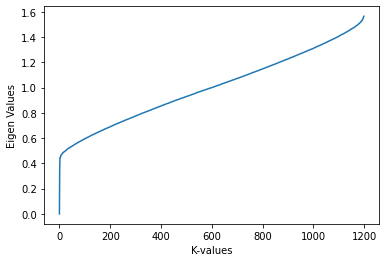

In [345]:
temp_values = []
for i in range(len(eigen_values)):
    temp_values.append((eigen_values[i],i))
temp_values.sort()
temp_vectors = []
for i,j in temp_values:
    temp_vectors.append(j)

eigen_vecs = eigen_vectors[:,temp_vectors]
eigen_vals = eigen_values[temp_vectors]

plt.ylabel('Eigen Values') 
plt.xlabel('K-values')
plt.plot(np.array(eigen_vals).tolist()) 

difference = 0
no_of_clusters = -1
for i in range(1,len(eigen_vals)-1):
    if (eigen_vals[i+1]-eigen_vals[i])<= difference:
        continue
    else:
        difference = eigen_vals[i+1]-eigen_vals[i]
        no_of_clusters=i+1
        
print('No of clusters: ',no_of_clusters)



In [346]:
kmeans = KMeans(n_clusters=no_of_clusters,n_init='auto',random_state=42).fit(eigen_vecs[:,1:no_of_clusters])
clusters = {} 
for i in kmeans.labels_:
    if i not in clusters.keys():
        clusters[i]=1
    else :
        clusters[i]+=1

print("Clusters:",kmeans.labels_)
print('No of clusters:',no_of_clusters)
print('Number of samples in clusters:' ,clusters)

Clusters: [1 0 1 ... 0 0 0]
No of clusters: 2
Number of samples in clusters: {1: 398, 0: 801}


In [347]:
labels=kmeans.labels_
no_of_data_points = np.bincount(labels)
min_data_point = np.argmin(no_of_data_points)
outliers = eigen_vecs[:,1:no_of_clusters][labels == min_data_point]

print('No.of outliers:',len(outliers))


No.of outliers: 398
